# 01 — Matching de 253 pulsos reales

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

DATA_CORSIKA = PROJECT_ROOT / "data/raw/corsika/DATA_PROCESADA_ANTONIO_ROMERO.csv"
DATA_REAL = PROJECT_ROOT / "data/raw/real/10min.csv"

OUTPUT_TABLES = PROJECT_ROOT / "outputs/tables/peak_matched_all_253"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs/figures/peak_matched_all_253"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("CORSIKA exists:", DATA_CORSIKA.exists(), DATA_CORSIKA)
print("HEP exists:", DATA_REAL.exists(), DATA_REAL)

Project root: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework
Python: c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\.venv\Scripts\python.exe
CORSIKA exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\corsika\DATA_PROCESADA_ANTONIO_ROMERO.csv
HEP exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\real\10min.csv


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from tambo_sipm import load_simulation_config
from tambo_sipm.io import (
    build_photon_events,
    detector_summary,
    load_romero_photon_table,
    load_segmented_hep_pulses,
    pulse_collection_to_dict,
    pulse_lengths,
)
from tambo_sipm.analysis import (
    compare_real_sim_features,
    extract_features_from_pulse_table,
    summarize_feature_table,
)
from tambo_sipm.simulation import build_calibration_config
from tambo_sipm.simulation.batch import simulate_feature_row_from_photon_event
from tambo_sipm.detector import simulate_detector_event_from_config
from tambo_sipm.plotting import plot_waveform_overlay, save_figure

THRESHOLD_MV = 18.0
N_PRETRIGGER_SAMPLES = 3
GAP_THRESHOLD_NS = 50.0
RANDOM_SEED = 42

# Parámetros exploratorios que estás probando actualmente.
ETA_TRANSPORT = 0.025
TAU_F_NS = 220.0
ARRIVAL_SPREAD_NS = 20.0

# Pool grande para buscar candidatos. Si demora mucho, bajar a 8000-12000.
MAX_POOL_EVENTS = 20000

FEATURE_COLUMNS = ["peak_mV", "rms_mV", "integral_mVns", "width_ns"]

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10

print("Imports OK")

Imports OK


## 1. Cargar los 253 pulsos reales HEP sin filtrar

Aquí se segmentan los pulsos reales desde `10min.csv`. Luego se extraen features, pero **no se filtran** para el matching final. Para emparejar los 253 pulsos usaremos `raw_peak_mV`, que existe incluso para pulsos que no pasan el umbral de validez.

In [3]:
real_pulses = load_segmented_hep_pulses(
    DATA_REAL,
    gap_threshold_ns=GAP_THRESHOLD_NS,
    min_samples=2,
)

real_lengths = pulse_lengths(real_pulses)
real_features = extract_features_from_pulse_table(
    real_pulses,
    threshold_mV=THRESHOLD_MV,
    n_pretrigger_samples=N_PRETRIGGER_SAMPLES,
)

real_waveforms = pulse_collection_to_dict(real_pulses)

print("Pulsos HEP segmentados:", real_pulses["event_id"].nunique())
print("Filas en real_features:", len(real_features))
print("Pulsos válidos según threshold:", int(real_features["valid"].sum()))
print("Pulsos no válidos según threshold:", int((~real_features["valid"]).sum()))

display(summarize_feature_table(real_features))
display(real_features[["event_id", "valid", "extraction_status", "raw_peak_mV", "peak_mV", "width_ns", "integral_mVns"]].head())
display(real_features[["raw_peak_mV", "peak_mV", "width_ns", "integral_mVns"]].describe())

real_pulses.to_csv(OUTPUT_TABLES / "real_pulses_253.csv", index=False)
real_features.to_csv(OUTPUT_TABLES / "real_features_253.csv", index=False)
real_lengths.to_csv(OUTPUT_TABLES / "real_pulse_lengths_253.csv", index=False)

Pulsos HEP segmentados: 253
Filas en real_features: 253
Pulsos válidos según threshold: 239
Pulsos no válidos según threshold: 14


,extraction_status,valid,count
0,ok,True,239
1,ok,False,10
2,too_short_for_baseline,False,4


,event_id,valid,extraction_status,raw_peak_mV,peak_mV,width_ns,integral_mVns
0,real_pulse_00000,True,ok,37.202,34.770,160.0,4333.440
1,real_pulse_00001,True,ok,67.214,65.514,296.0,11206.432
2,real_pulse_00002,True,ok,37.324,32.574,136.0,3450.648
3,real_pulse_00003,True,ok,39.276,36.966,168.0,4694.072
4,real_pulse_00004,True,ok,32.444,29.036,112.0,2761.104


,raw_peak_mV,peak_mV,width_ns,integral_mVns
count,253.000000,249.000000,249.000000,249.000000
mean,53.031621,50.340924,208.385543,7607.755372
std,25.863632,26.647182,90.597191,5920.715873
min,1.090000,0.976000,0.000000,0.000000
25%,37.690000,35.624000,152.000000,4158.736000
50%,44.400000,43.066000,192.000000,5808.175873
75%,59.040000,57.584000,256.000000,9067.528000
max,204.952000,203.374000,512.000000,40926.120000


## 2. Construir pool CORSIKA usando todos los detectores

Esto elimina temporalmente el constraint de `Detector 0`. Es útil para el matched comparison exploratorio porque aumenta el número de candidatos simulados.

In [4]:
corsika_table = load_romero_photon_table(DATA_CORSIKA)

print("Resumen por detector:")
display(detector_summary(corsika_table))

available_detectors = sorted(corsika_table["Detector"].dropna().astype(int).unique())
print("Detectores disponibles:", available_detectors)

def build_all_detector_events(corsika_dataframe):
    event_tables = []

    for detector in available_detectors:
        events = build_photon_events(corsika_dataframe, detector=int(detector)).copy()
        events["detector"] = int(detector)
        if "source_row" in events.columns:
            events["event_id"] = [
                f"corsika_d{int(detector)}_row{int(row)}"
                for row in events["source_row"]
            ]
        else:
            events["event_id"] = [
                f"corsika_d{int(detector)}_idx{idx}"
                for idx in range(len(events))
            ]
        event_tables.append(events)

    return pd.concat(event_tables, ignore_index=True)

corsika_events_all = build_all_detector_events(corsika_table)

print("Eventos CORSIKA usando todos los detectores:", len(corsika_events_all))
display(corsika_events_all.head())
display(corsika_events_all["detector"].value_counts().sort_index())

corsika_events_all.to_csv(OUTPUT_TABLES / "corsika_all_detectors_events.csv", index=False)

Resumen por detector:


,Detector,rows,unique_showers,total_photons,mean_photons,median_photons,min_photons,max_photons
0,0.0,26777,9862,763901469,28528.269373,5387.0,949,18807617
1,1.0,6616,4737,90889255,13737.795496,3327.5,949,2946734
2,2.0,6472,4632,82816395,12796.105532,3287.5,950,2508031
3,3.0,6417,4508,87813188,13684.461275,3359.0,949,1897897


Detectores disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Eventos CORSIKA usando todos los detectores: 46282


,event_id,source_row,detector,shower,particle_id,particle_name,particle_category,generated_photons,n_hits,particle_name_original,t,x,y,ek,carga,masa_MeV,energia_detectada_poli_MeV,tiempo_deteccion
0,corsika_d0_row2,2,0,18,1,gamma,electromagnetic,63228,1,foton,2.669530,0.250841,0.125899,474.3080,0,0.00,7.903448,5.440774
1,corsika_d0_row6,6,0,56,6,mu-,muonic,17156,1,muon-,4.166519,-0.225720,-0.097985,930.5940,-1,105.66,2.144515,8.491790
2,corsika_d0_row8,8,0,63,1,gamma,electromagnetic,2527,1,foton,2.351932,0.406301,-0.186175,18.1535,0,0.00,0.315862,4.793476
3,corsika_d0_row10,10,0,68,1,gamma,electromagnetic,2613,1,foton,6.082793,-0.707285,-0.190728,19.0195,0,0.00,0.326669,12.397351
4,corsika_d0_row11,11,0,71,1,gamma,electromagnetic,2079,1,foton,4.841286,-0.471563,0.054370,13.6359,0,0.00,0.259903,9.867033


detector
0    26777
1     6616
2     6472
3     6417
Name: count, dtype: int64

## 3. Configuración de simulación

Se mantiene fijo:

- `voltage_scale_mV_per_pe = 0.12`
- `pde = 0.41`

Y se usa la configuración exploratoria actual:

- `transport_efficiency = 0.025`
- `tau_f_ns = 220 ns`
- `arrival_spread_ns = 20 ns`

In [5]:
base_config = load_simulation_config()

matched_config = build_calibration_config(
    base_config,
    transport_efficiency=ETA_TRANSPORT,
    tau_f_ns=TAU_F_NS,
    arrival_spread_ns=ARRIVAL_SPREAD_NS,
)

print("Fixed voltage_scale_mV_per_pe:", matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"])
print("Fixed PDE:", matched_config["photon_transport"]["pde"])
print("η_transport:", matched_config["photon_transport"]["transport_efficiency"])
print("tau_f_ns:", matched_config["sipm_response"]["tau_f_ns"])
print("arrival_spread_ns:", matched_config["sipm_response"]["arrival_spread_ns"])

Fixed voltage_scale_mV_per_pe: 0.12
Fixed PDE: 0.41
η_transport: 0.025
tau_f_ns: 220.0
arrival_spread_ns: 20.0


## 4. Simular pool grande con semillas guardadas

Para poder reconstruir exactamente los waveforms simulados emparejados, cada evento simulado guarda su `simulation_seed`.

In [6]:
def simulate_feature_pool_with_seeds(
    photon_events,
    config,
    max_events=20000,
    random_seed=42,
    threshold_mV=18.0,
    n_pretrigger_samples=3,
):
    n_events = min(max_events, len(photon_events))

    selected_events = (
        photon_events
        .sample(n=n_events, random_state=random_seed)
        .reset_index(drop=True)
    )

    rows = []

    for local_index, (_, event_row) in enumerate(selected_events.iterrows()):
        simulation_seed = int(random_seed * 1_000_000 + local_index)
        rng = np.random.default_rng(simulation_seed)

        feature_row = simulate_feature_row_from_photon_event(
            event_row=event_row,
            config=config,
            threshold_mV=threshold_mV,
            n_pretrigger_samples=n_pretrigger_samples,
            rng=rng,
        )

        feature_row["simulation_seed"] = simulation_seed
        feature_row["pool_local_index"] = local_index
        rows.append(feature_row)

    return pd.DataFrame(rows)

sim_pool_features = simulate_feature_pool_with_seeds(
    photon_events=corsika_events_all,
    config=matched_config,
    max_events=MAX_POOL_EVENTS,
    random_seed=RANDOM_SEED,
    threshold_mV=THRESHOLD_MV,
    n_pretrigger_samples=N_PRETRIGGER_SAMPLES,
)

print("Pool simulado:", len(sim_pool_features))
print("Válidos por threshold:", int(sim_pool_features["valid"].sum()))
print("No válidos por threshold:", int((~sim_pool_features["valid"]).sum()))

display(sim_pool_features[["event_id", "detector", "generated_photons", "raw_peak_mV", "peak_mV", "valid", "simulation_seed"]].head())
display(sim_pool_features[["raw_peak_mV", "peak_mV", "width_ns", "integral_mVns"]].describe())

sim_pool_features.to_csv(OUTPUT_TABLES / "sim_pool_all_detectors_features_with_seeds.csv", index=False)

Pool simulado: 20000
Válidos por threshold: 1998
No válidos por threshold: 18002


,event_id,detector,generated_photons,raw_peak_mV,peak_mV,valid,simulation_seed
0,corsika_d0_row17194,0,43232,50.781250,23.193359,True,42000000
1,corsika_d1_row8747,1,2932,4.272461,1.708984,False,42000001
2,corsika_d0_row3171,0,2950,3.662109,2.319336,False,42000002
3,corsika_d0_row5314,0,100238,113.281250,59.936523,True,42000003
4,corsika_d1_row3322,1,19006,20.507812,10.986328,False,42000004


,raw_peak_mV,peak_mV,width_ns,integral_mVns
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.552271,10.074139,8.922400,528.897754
std,63.767689,28.098434,31.603631,3060.770799
min,0.000000,0.000000,0.000000,0.000000
25%,2.075195,1.098633,0.000000,0.000000
50%,5.004883,2.563477,0.000000,0.000000
75%,20.751953,10.620117,0.000000,0.000000
max,999.877930,510.131836,192.000000,56104.003906


## 5. Matching de los 253 pulsos HEP usando `raw_peak_mV`

Este matching no filtra HEP por validez. Usa los 253 pulsos reales y busca 253 pulsos simulados sin reemplazo. La variable principal de matching es `raw_peak_mV`, porque existe para todos los pulsos, incluso si no pasan el umbral.

Este procedimiento prioriza la distribución de picos. Puede no optimizar ancho ni integral.

In [7]:
real_match_all = real_features.copy().reset_index(drop=True)
real_match_all["match_peak_mV"] = pd.to_numeric(real_match_all["raw_peak_mV"], errors="coerce")

sim_match_pool = sim_pool_features.copy().reset_index(drop=True)
sim_match_pool["match_peak_mV"] = pd.to_numeric(sim_match_pool["raw_peak_mV"], errors="coerce")

real_match_all = real_match_all[np.isfinite(real_match_all["match_peak_mV"])].copy().reset_index(drop=True)
sim_match_pool = sim_match_pool[np.isfinite(sim_match_pool["match_peak_mV"])].copy().reset_index(drop=True)

print("HEP disponibles para matching:", len(real_match_all))
print("Simulados disponibles para matching:", len(sim_match_pool))
assert len(real_match_all) == real_pulses["event_id"].nunique(), "No se están usando los 253 pulsos HEP."
assert len(sim_match_pool) >= len(real_match_all), "No hay suficientes simulados para emparejar."


def greedy_peak_match_without_replacement(real_df, sim_df, peak_column="match_peak_mV"):
    real_sorted = (
        real_df
        .reset_index(names="real_original_index")
        .sort_values(peak_column)
        .reset_index(drop=True)
    )

    sim_available = sim_df.reset_index(names="sim_original_index").copy().reset_index(drop=True)
    available_positions = list(range(len(sim_available)))

    match_rows = []
    selected_sim_positions = []

    for match_id, real_row in real_sorted.iterrows():
        real_peak = float(real_row[peak_column])
        candidate_peaks = sim_available.iloc[available_positions][peak_column].to_numpy(dtype=float)
        best_local_position = int(np.argmin(np.abs(candidate_peaks - real_peak)))
        best_global_position = available_positions.pop(best_local_position)
        sim_row = sim_available.iloc[best_global_position]
        sim_peak = float(sim_row[peak_column])

        selected_sim_positions.append(best_global_position)
        match_rows.append(
            {
                "match_id": int(match_id),
                "real_original_index": int(real_row["real_original_index"]),
                "sim_original_index": int(sim_row["sim_original_index"]),
                "real_event_id": str(real_row["event_id"]),
                "simulated_event_id": str(sim_row["event_id"]),
                "real_match_peak_mV": real_peak,
                "simulated_match_peak_mV": sim_peak,
                "delta_peak_mV": sim_peak - real_peak,
                "abs_delta_peak_mV": abs(sim_peak - real_peak),
            }
        )

    match_table = pd.DataFrame(match_rows)

    matched_real = real_sorted.copy()
    matched_sim = sim_available.iloc[selected_sim_positions].copy().reset_index(drop=True)

    matched_real["match_id"] = match_table["match_id"].to_numpy(dtype=int)
    matched_sim["match_id"] = match_table["match_id"].to_numpy(dtype=int)
    matched_sim["matched_real_event_id"] = match_table["real_event_id"].to_numpy()
    matched_sim["abs_delta_peak_mV"] = match_table["abs_delta_peak_mV"].to_numpy(dtype=float)

    return matched_real, matched_sim, match_table

matched_real_all253, matched_sim_all253, peak_match_table_all253 = greedy_peak_match_without_replacement(
    real_match_all,
    sim_match_pool,
    peak_column="match_peak_mV",
)

print("Pares emparejados:", len(peak_match_table_all253))
display(peak_match_table_all253.describe())
display(peak_match_table_all253.head())

matched_real_all253.to_csv(OUTPUT_TABLES / "matched_real_all_253_by_raw_peak.csv", index=False)
matched_sim_all253.to_csv(OUTPUT_TABLES / "matched_sim_all_253_by_raw_peak.csv", index=False)
peak_match_table_all253.to_csv(OUTPUT_TABLES / "peak_match_table_all_253.csv", index=False)

HEP disponibles para matching: 253
Simulados disponibles para matching: 20000
Pares emparejados: 253


,match_id,real_original_index,sim_original_index,real_match_peak_mV,simulated_match_peak_mV,delta_peak_mV,abs_delta_peak_mV
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,126.000000,126.000000,5595.735178,53.031621,53.052819,0.021199,0.043761
std,73.179004,73.179004,5053.789661,25.863632,25.834564,0.068100,0.056268
min,0.000000,0.000000,0.000000,1.090000,1.098633,-0.861477,0.008633
25%,63.000000,63.000000,1625.000000,37.690000,37.719727,0.028602,0.029586
50%,126.000000,126.000000,3782.000000,44.400000,44.433594,0.031344,0.033594
75%,189.000000,189.000000,8214.000000,59.040000,59.082031,0.038023,0.042453
max,252.000000,252.000000,19919.000000,204.952000,204.833984,0.172539,0.861477


,match_id,real_original_index,sim_original_index,real_event_id,simulated_event_id,real_match_peak_mV,simulated_match_peak_mV,delta_peak_mV,abs_delta_peak_mV
0,0,14,15,real_pulse_00014,corsika_d0_row8030,1.090,1.098633,0.008633,0.008633
1,1,28,1044,real_pulse_00028,corsika_d0_row31623,16.096,16.113281,0.017281,0.017281
2,2,17,245,real_pulse_00017,corsika_d0_row14019,18.292,18.310547,0.018547,0.018547
3,3,25,1080,real_pulse_00025,corsika_d0_row14184,26.588,26.611328,0.023328,0.023328
4,4,4,1263,real_pulse_00004,corsika_d1_row7023,32.444,32.470703,0.026703,0.026703


## 6. Funciones de gráficos normalizados

Todos los histogramas comparativos se normalizan como fracción de eventos. Los histogramas temporales de `width_ns` usan bins de 8 ns.

In [8]:
def temporal_bins_8ns(*arrays, margin_bins=1):
    values = np.concatenate([np.asarray(array, dtype=float) for array in arrays])
    values = values[np.isfinite(values)]
    lower = 8.0 * np.floor(values.min() / 8.0) - margin_bins * 8.0
    upper = 8.0 * np.ceil(values.max() / 8.0) + margin_bins * 8.0
    return np.arange(lower, upper + 8.0, 8.0)


def common_linear_bins(*arrays, n_bins=40):
    values = np.concatenate([np.asarray(array, dtype=float) for array in arrays])
    values = values[np.isfinite(values)]
    lower = values.min()
    upper = values.max()
    if lower == upper:
        lower -= 0.5
        upper += 0.5
    return np.linspace(lower, upper, n_bins + 1)


def normalized_weights(values):
    values = np.asarray(values)
    return np.ones(len(values), dtype=float) / max(len(values), 1)


def plot_normalized_hist_comparison(
    reference,
    candidate,
    bins,
    xlabel,
    title,
    reference_label="Real HEP",
    candidate_label="Simulated",
    output_path=None,
):
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(
        reference,
        bins=bins,
        weights=normalized_weights(reference),
        histtype="step",
        linewidth=1.8,
        label=reference_label,
    )
    ax.hist(
        candidate,
        bins=bins,
        weights=normalized_weights(candidate),
        histtype="step",
        linewidth=1.8,
        label=candidate_label,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fraction")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if output_path is not None:
        save_figure(fig, output_path)

    plt.show()


def plot_side_by_side_hist2d_normalized(
    real_df,
    sim_df,
    x_column,
    y_column,
    x_label,
    y_label,
    title_left,
    title_right,
    output_path=None,
    x_bins=40,
    y_bins=40,
):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)

    for ax, df, title in [
        (axes[0], real_df, title_left),
        (axes[1], sim_df, title_right),
    ]:
        weights = np.ones(len(df), dtype=float) / max(len(df), 1)
        hist = ax.hist2d(
            df[x_column],
            df[y_column],
            bins=[x_bins, y_bins],
            weights=weights,
        )
        fig.colorbar(hist[3], ax=ax, label="Fraction")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(title)

    fig.tight_layout()

    if output_path is not None:
        save_figure(fig, output_path)

    plt.show()

## 7. Histogramas normalizados de picos, RMS, integral y ancho

Para el matching de 253 pulsos se prioriza la comparación de `raw_peak_mV`. Para las otras variables se muestran las features disponibles cuando son finitas.

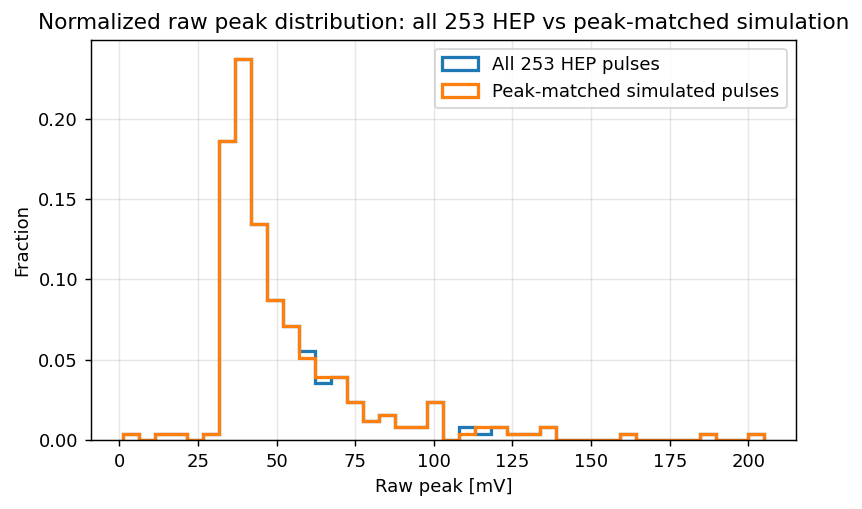

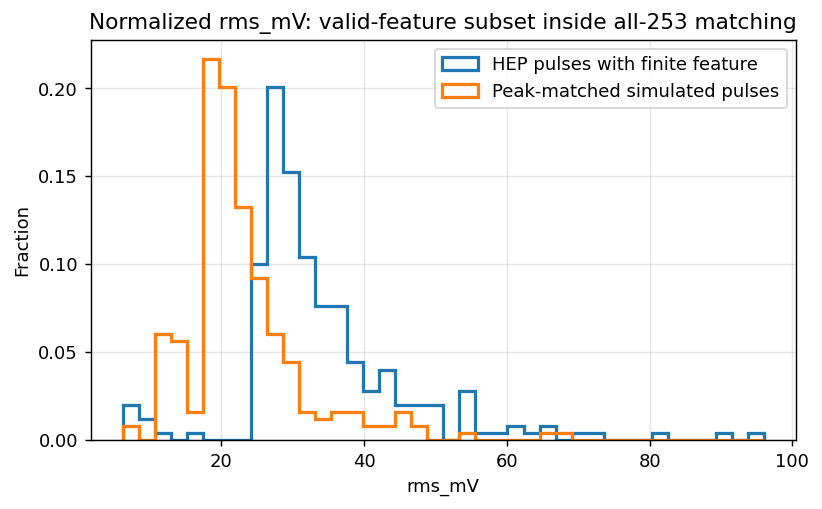

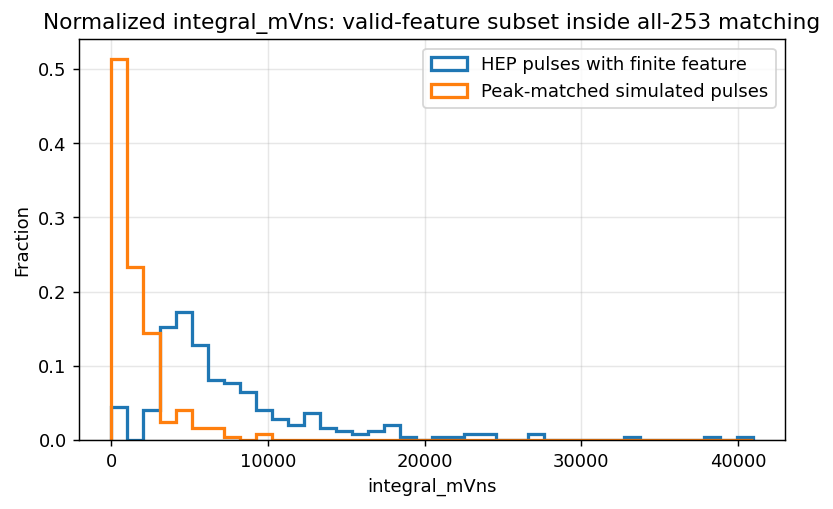

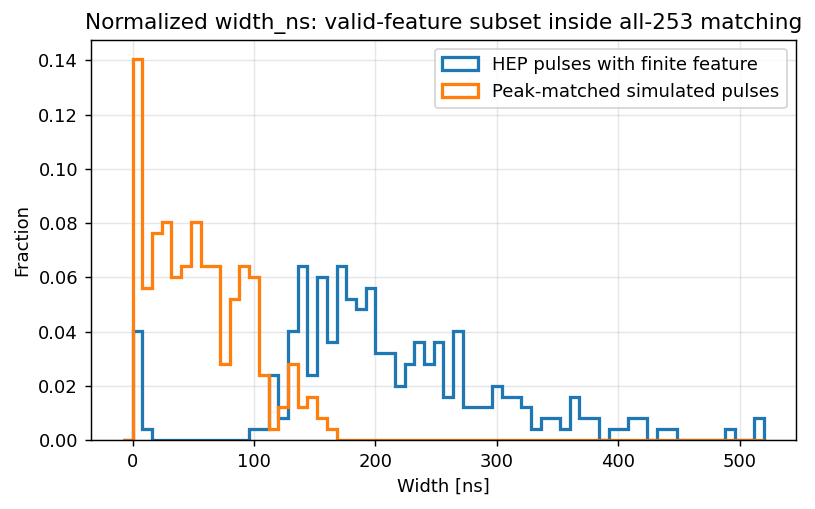

In [9]:
plot_normalized_hist_comparison(
    reference=matched_real_all253["match_peak_mV"],
    candidate=matched_sim_all253["match_peak_mV"],
    bins=common_linear_bins(matched_real_all253["match_peak_mV"], matched_sim_all253["match_peak_mV"], n_bins=40),
    xlabel="Raw peak [mV]",
    title="Normalized raw peak distribution: all 253 HEP vs peak-matched simulation",
    reference_label="All 253 HEP pulses",
    candidate_label="Peak-matched simulated pulses",
    output_path=OUTPUT_FIGURES / "normalized_hist_raw_peak_all253_vs_peak_matched.png",
)

for feature in ["rms_mV", "integral_mVns", "width_ns"]:
    real_values = pd.to_numeric(matched_real_all253[feature], errors="coerce")
    sim_values = pd.to_numeric(matched_sim_all253[feature], errors="coerce")
    mask = np.isfinite(real_values) & np.isfinite(sim_values)

    if feature == "width_ns":
        bins = temporal_bins_8ns(real_values[mask], sim_values[mask])
        xlabel = "Width [ns]"
    else:
        bins = common_linear_bins(real_values[mask], sim_values[mask], n_bins=40)
        xlabel = feature

    plot_normalized_hist_comparison(
        reference=real_values[mask],
        candidate=sim_values[mask],
        bins=bins,
        xlabel=xlabel,
        title=f"Normalized {feature}: valid-feature subset inside all-253 matching",
        reference_label="HEP pulses with finite feature",
        candidate_label="Peak-matched simulated pulses",
        output_path=OUTPUT_FIGURES / f"normalized_hist_{feature}_all253_peak_matched.png",
    )

## 8. Histogramas 2D normalizados

Los 2D con `peak` usan `match_peak_mV`. Los 2D con `width` usan bins temporales de 8 ns.

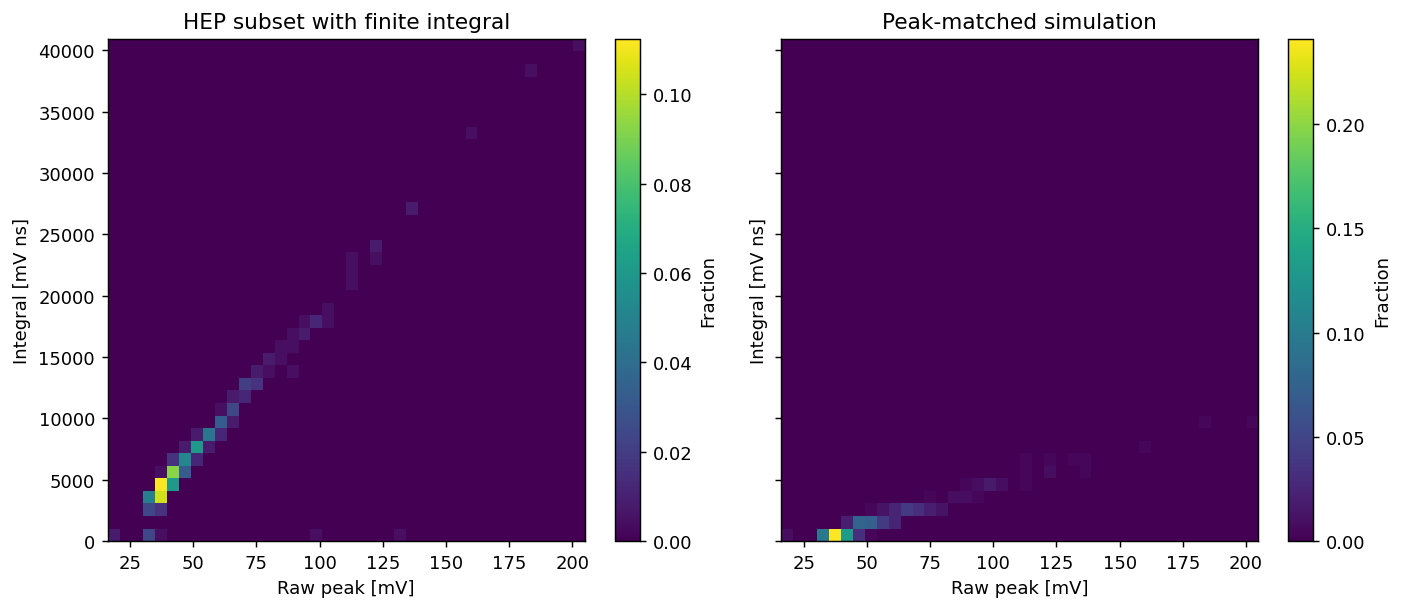

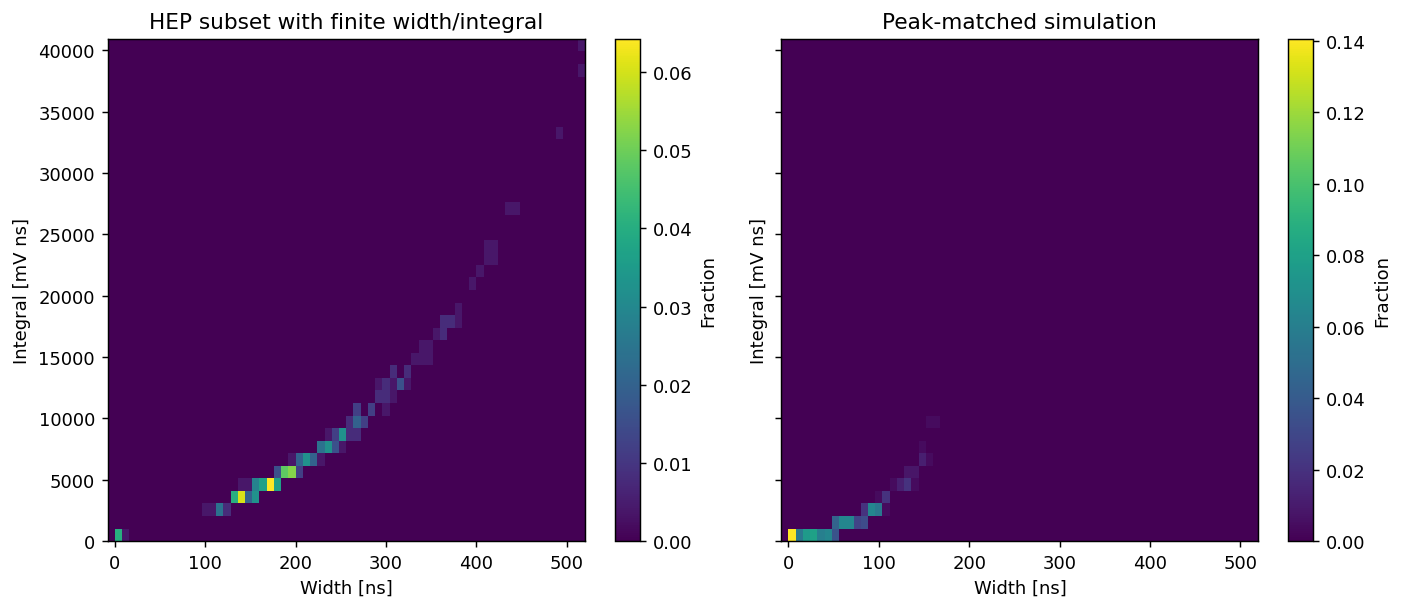

In [10]:
# 2D: Integral vs raw peak, usando solo pares con integral finita.
mask_integral = (
    np.isfinite(pd.to_numeric(matched_real_all253["integral_mVns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_sim_all253["integral_mVns"], errors="coerce"))
)

real_int_peak = matched_real_all253[mask_integral].copy()
sim_int_peak = matched_sim_all253[mask_integral].copy()

peak_bins = common_linear_bins(real_int_peak["match_peak_mV"], sim_int_peak["match_peak_mV"], n_bins=40)
integral_bins = common_linear_bins(real_int_peak["integral_mVns"], sim_int_peak["integral_mVns"], n_bins=40)

plot_side_by_side_hist2d_normalized(
    real_df=real_int_peak,
    sim_df=sim_int_peak,
    x_column="match_peak_mV",
    y_column="integral_mVns",
    x_label="Raw peak [mV]",
    y_label="Integral [mV ns]",
    title_left="HEP subset with finite integral",
    title_right="Peak-matched simulation",
    output_path=OUTPUT_FIGURES / "normalized_hist2d_integral_vs_raw_peak_all253_peak_matched.png",
    x_bins=peak_bins,
    y_bins=integral_bins,
)

# 2D: Integral vs width, usando pares con width e integral finitos.
mask_width_integral = (
    np.isfinite(pd.to_numeric(matched_real_all253["width_ns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_sim_all253["width_ns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_real_all253["integral_mVns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_sim_all253["integral_mVns"], errors="coerce"))
)

real_width_int = matched_real_all253[mask_width_integral].copy()
sim_width_int = matched_sim_all253[mask_width_integral].copy()

width_bins = temporal_bins_8ns(real_width_int["width_ns"], sim_width_int["width_ns"])
integral_bins_w = common_linear_bins(real_width_int["integral_mVns"], sim_width_int["integral_mVns"], n_bins=40)

plot_side_by_side_hist2d_normalized(
    real_df=real_width_int,
    sim_df=sim_width_int,
    x_column="width_ns",
    y_column="integral_mVns",
    x_label="Width [ns]",
    y_label="Integral [mV ns]",
    title_left="HEP subset with finite width/integral",
    title_right="Peak-matched simulation",
    output_path=OUTPUT_FIGURES / "normalized_hist2d_integral_vs_width_all253_peak_matched.png",
    x_bins=width_bins,
    y_bins=integral_bins_w,
)

## 9. Reconstrucción de waveforms simulados emparejados

Se reconstruyen exactamente con la semilla guardada para cada evento simulado.

In [11]:
def reconstruct_simulated_waveform(row, config):
    rng = np.random.default_rng(int(row["simulation_seed"]))
    result = simulate_detector_event_from_config(
        generated_photons=int(row["generated_photons"]),
        config=config,
        rng=rng,
    )
    return result.sampled_time_ns, result.digitized_voltage_mV

sim_matched_waveforms = {}
for _, row in matched_sim_all253.iterrows():
    sim_matched_waveforms[str(row["event_id"])] = reconstruct_simulated_waveform(row, matched_config)

print("Waveforms simulados reconstruidos:", len(sim_matched_waveforms))

Waveforms simulados reconstruidos: 253


## 10. Overlays usando pares emparejados

Primero se grafican **todos los 253 pares** con transparencia baja. Luego se grafica un subconjunto representativo por cuantiles de pico, solo para que la imagen sea legible. Ese subconjunto no cambia el análisis.

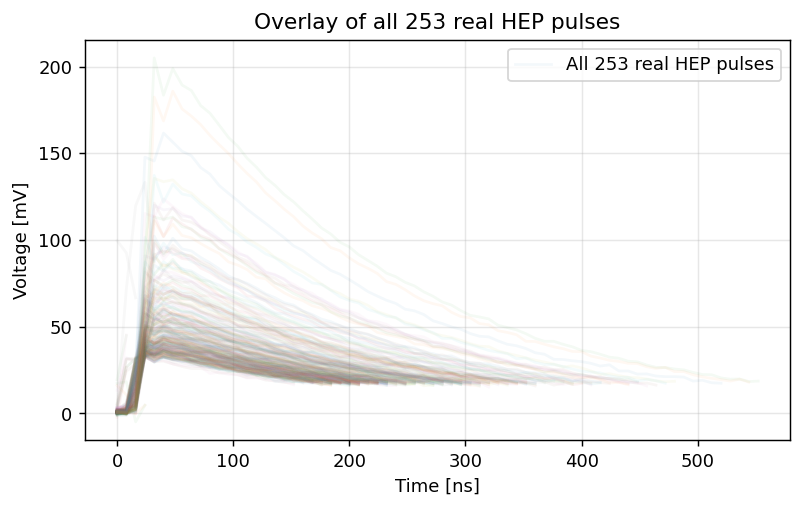

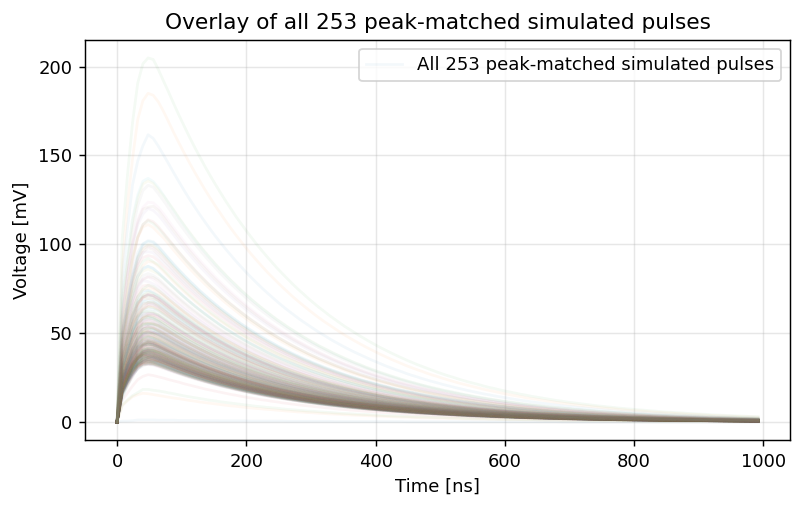

In [12]:
# Todos los 253 pares.
all_real_pair_waveforms = [
    real_waveforms[event_id]
    for event_id in matched_real_all253["event_id"]
    if event_id in real_waveforms
]

all_sim_pair_waveforms = [
    sim_matched_waveforms[event_id]
    for event_id in matched_sim_all253["event_id"]
    if event_id in sim_matched_waveforms
]

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(
    waveforms=all_real_pair_waveforms,
    xlabel="Time [ns]",
    ylabel="Voltage [mV]",
    label="All 253 real HEP pulses",
    alpha=0.05,
    ax=ax,
)
ax.set_title("Overlay of all 253 real HEP pulses")
save_figure(fig, OUTPUT_FIGURES / "overlay_all253_real_hep_pulses.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(
    waveforms=all_sim_pair_waveforms,
    xlabel="Time [ns]",
    ylabel="Voltage [mV]",
    label="All 253 peak-matched simulated pulses",
    alpha=0.05,
    ax=ax,
)
ax.set_title("Overlay of all 253 peak-matched simulated pulses")
save_figure(fig, OUTPUT_FIGURES / "overlay_all253_peak_matched_simulated_pulses.png")
plt.show()

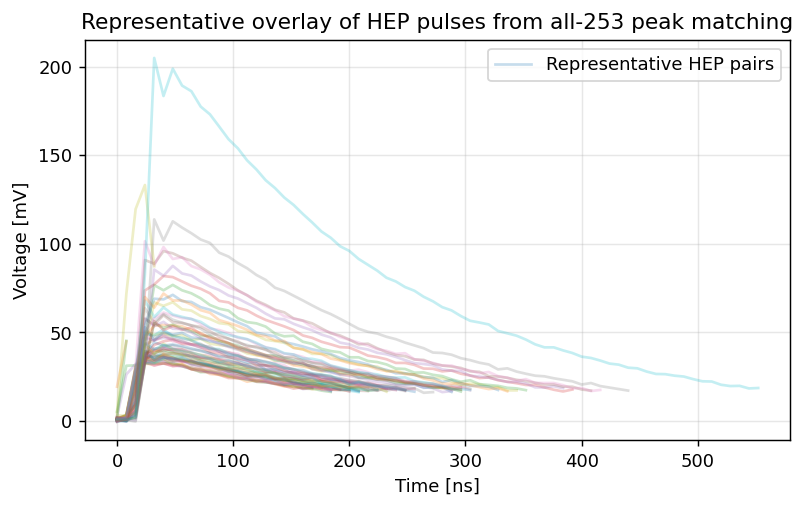

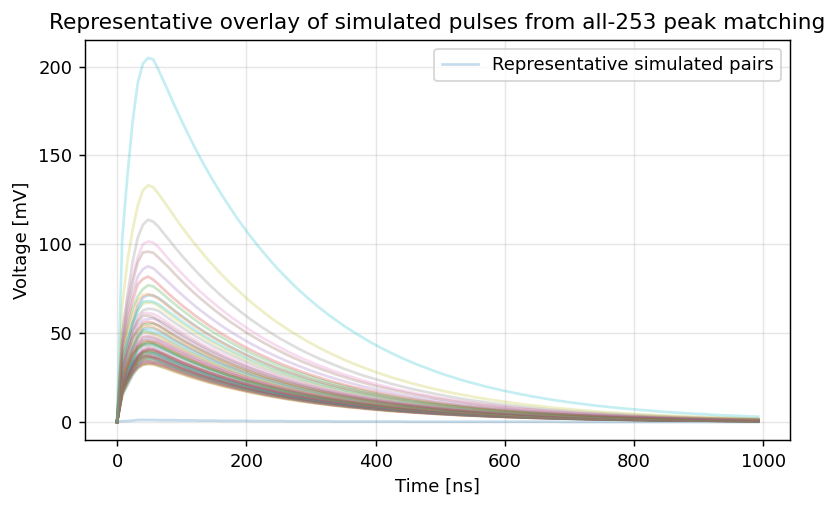

In [13]:
# Subconjunto representativo por cuantiles de pico.
# No filtra el análisis: solo selecciona líneas legibles para el overlay.
N_REPRESENTATIVE_PAIRS = 60

pair_order = peak_match_table_all253.sort_values("real_match_peak_mV").reset_index(drop=True)
representative_positions = np.linspace(
    0,
    len(pair_order) - 1,
    min(N_REPRESENTATIVE_PAIRS, len(pair_order)),
).astype(int)
representative_match_ids = pair_order.iloc[representative_positions]["match_id"].astype(int).tolist()

rep_real = matched_real_all253[matched_real_all253["match_id"].isin(representative_match_ids)].copy()
rep_sim = matched_sim_all253[matched_sim_all253["match_id"].isin(representative_match_ids)].copy()

rep_real = rep_real.sort_values("match_peak_mV")
rep_sim = rep_sim.set_index("match_id").loc[rep_real["match_id"]].reset_index()

rep_real_waveforms = [
    real_waveforms[event_id]
    for event_id in rep_real["event_id"]
    if event_id in real_waveforms
]

rep_sim_waveforms = [
    sim_matched_waveforms[event_id]
    for event_id in rep_sim["event_id"]
    if event_id in sim_matched_waveforms
]

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(
    waveforms=rep_real_waveforms,
    xlabel="Time [ns]",
    ylabel="Voltage [mV]",
    label="Representative HEP pairs",
    alpha=0.25,
    ax=ax,
)
ax.set_title("Representative overlay of HEP pulses from all-253 peak matching")
save_figure(fig, OUTPUT_FIGURES / "overlay_representative_real_all253_peak_matched_pairs.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(
    waveforms=rep_sim_waveforms,
    xlabel="Time [ns]",
    ylabel="Voltage [mV]",
    label="Representative simulated pairs",
    alpha=0.25,
    ax=ax,
)
ax.set_title("Representative overlay of simulated pulses from all-253 peak matching")
save_figure(fig, OUTPUT_FIGURES / "overlay_representative_sim_all253_peak_matched_pairs.png")
plt.show()

## 11. Resumen cuantitativo

La métrica principal aquí es la diferencia de pico entre cada pulso HEP y su simulado emparejado.

In [14]:
summary = pd.DataFrame(
    {
        "metric": [
            "n_real_hep_pulses_used",
            "n_simulated_pool_events",
            "n_matched_pairs",
            "mean_abs_delta_raw_peak_mV",
            "median_abs_delta_raw_peak_mV",
            "max_abs_delta_raw_peak_mV",
            "eta_transport",
            "tau_f_ns",
            "arrival_spread_ns",
            "fixed_voltage_scale_mV_per_pe",
            "fixed_pde",
        ],
        "value": [
            len(real_match_all),
            len(sim_pool_features),
            len(peak_match_table_all253),
            peak_match_table_all253["abs_delta_peak_mV"].mean(),
            peak_match_table_all253["abs_delta_peak_mV"].median(),
            peak_match_table_all253["abs_delta_peak_mV"].max(),
            ETA_TRANSPORT,
            TAU_F_NS,
            ARRIVAL_SPREAD_NS,
            matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"],
            matched_config["photon_transport"]["pde"],
        ],
    }
)

display(summary)
summary.to_csv(OUTPUT_TABLES / "summary_all253_peak_matching.csv", index=False)

print("Output tables:", OUTPUT_TABLES)
print("Output figures:", OUTPUT_FIGURES)

,metric,value
0,n_real_hep_pulses_used,253.000000
1,n_simulated_pool_events,20000.000000
2,n_matched_pairs,253.000000
3,mean_abs_delta_raw_peak_mV,0.043761
4,median_abs_delta_raw_peak_mV,0.033594
5,max_abs_delta_raw_peak_mV,0.861477
6,eta_transport,0.025000
7,tau_f_ns,220.000000
8,arrival_spread_ns,20.000000
9,fixed_voltage_scale_mV_per_pe,0.120000


Output tables: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\peak_matched_all_253
Output figures: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\peak_matched_all_253
